# Decision Tree Model Implementation

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

In [41]:
from sklearn.datasets import load_iris

iris=load_iris()

df=pd.DataFrame(iris.data,columns=iris.feature_names)
df['Flower']=iris.target
df['Flower']=df['Flower'].apply(lambda x: iris.target_names[x])

df.head()

X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [42]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

treeClassifier=DecisionTreeClassifier()
treeClassifier.fit(X_train,y_train)

DecisionTreeClassifier()

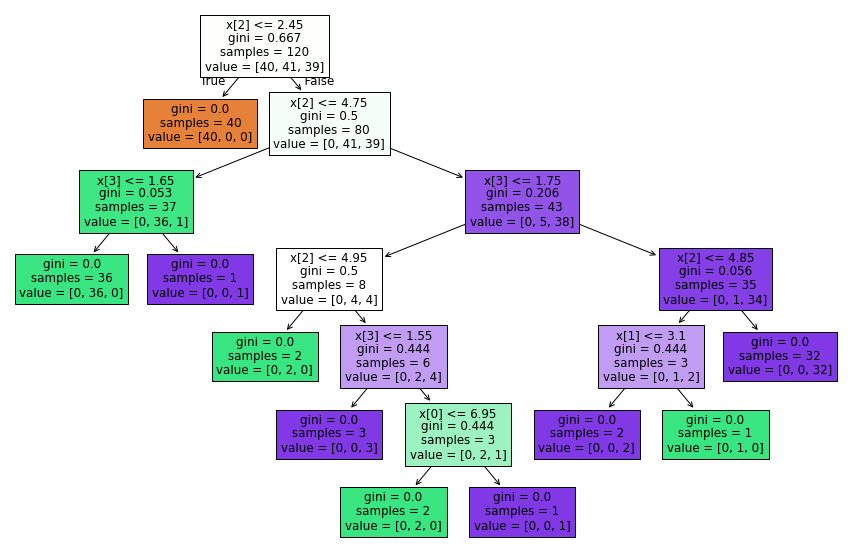

In [58]:
plt.figure(figsize=(15,10))
plot_tree(treeClassifier,filled=True);

In [45]:
y_pred=treeClassifier.predict(X_test)

In [46]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


## Postpruning and Prepruning

In [47]:
params={
    'criterion':['gini','entropy','log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
    
}

In [48]:
from sklearn.model_selection import GridSearchCV

grid=GridSearchCV(treeClassifier,param_grid=params,scoring='accuracy')

In [49]:
grid.fit(X_train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [50]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'max_features': 'sqrt',
 'splitter': 'random'}

In [51]:
y_pred=grid.predict(X_test)

In [53]:
grid.best_score_

0.95

In [52]:
from sklearn.metrics import classification_report,confusion_matrix

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
